<img src="https://userweb.fct.unl.pt/~jmc.xavier/MSI/iLogos/nsst.jpg" width="400" height="100">

# DEMI | NOVA SST

## Mecânica dos Sólidos I

## Torção de barras elásticas. Parte III
## Problema 3 <a name="PV133"></a>

O veio $ABCD$ é construído em aço ($E$ = 200 GPa, $G$ = 77 GPa, $\tau_c$ = 145 MPa) e é constituído por três troços: (i) no troço $AB$, o veio é oco e tem um diâmetro exterior de 100 mm e uma espessura de 5 mm; (ii) no troço $BC$ o veio é maciço, com diâmetro de 100 mm; (iii) no troço $CD$ o veio é também maciço, com diâmetro de 80 mm. Sabe-se que sobre o veio está aplicado um momento de torção $T$, de intensidade desconhecida, na extremidade $D$. Na periferia do veio, no troço $CD$ está colado o extensómetro $E$, cujo eixo faz um ângulo de 45º com o eixo do veio, como indicado na figura.

[a)](#A) Diga o que entende por comportamento elastoplástico.

[b)](#B) Sabendo que a extensão medida em $E$ é de 665 $\mu\varepsilon$, determine a intensidade do momento $T$ aplicado.

[c)](#C) Para o momento de torção calculado na alínea anterior, determine a distribuição de tensões tangenciais nos três troços do veio.

[d)](#D)  Devido ao momento $T$ aplicado, mediu-se uma rotação da secção $D$, $\phi_C$ = 3,5º. Determine a rotação que existirá nessa secção quando o momento $T$ for retirado, assim como a distribuição de tensões residuais no veio.

<img src="https://userweb.fct.unl.pt/~jmc.xavier/MSI/Notebooks/Au13/Au13_P003_i1.jpg"
width="400" height="300">

In [1]:
caminho = 'https://userweb.fct.unl.pt/~jmc.xavier/MSI/Notebooks/Au13/'

import numpy as np

import math
from matplotlib import pyplot as plt
from matplotlib.patches import Arc
import matplotlib.ticker as ticker

plt.rcParams['axes.facecolor'] = (.15, .15, .15)
plt.rcParams['figure.facecolor'] = (.15, .15, .15)
plt.rcParams['font.family'] = 'monospace'
plt.rcParams['font.size'] = 14
# plt.rcParams['text.usetex'] = True
params = {"ytick.color" : (.8, .8, .8),
          "xtick.color" : (.8, .8, .8),
          "grid.color" : (.2, .2, .2),
          "text.color" : (.7, .7, .7),
          "axes.labelcolor" : (.8, .8, .8),
          "axes.edgecolor" : (.15, .15, .15)}
plt.rcParams.update(params)

# Dados
# unidades: m, Pa, N

E, G = 200.e9, 77.e9
nu = E/2/G - 1
print(f'nu = {nu:.2f}')

dABe, espAB = 100.e-3, 5.e-3
rABe = dABe/2
print(f'rABe = {rABe:.3f} mm')
rABi = (dABe-2*espAB)/2
print(f'rABi = {rABi:.3f} mm')

dBC = 100.e-3
rBC = dBC/2

dCD = 80.e-3
rCD = dCD/2

LAB, LBC, LCD = 0.6, 0.2, 0.4

phiD = np.deg2rad(3.5)
print('phi D = ','{:.6f}'.format(phiD),' radianos | ','{:.3f}'.format(np.rad2deg(phiD)),' º')
epsE, TauC = 665.e-6, 145.e6

nu = 0.30
rABe = 0.050 mm
rABi = 0.045 mm
phi D =  0.061087  radianos |  3.500  º


#### a) Diga o que entende por comportamento elastoplástico.<a name="A"></a>  ([_enunciatum_](#PV133))

Um material com comportamento elasto-plástico perfeito é caracterizado por uma lei constitutiva tensão de corte - distorção angular para o qual o material sofre um incremento proporcional de distorção angular em relação à tensão de corte até o momento em que a tensão atinge a tensão de corte de cedência, $\tau_C$, no limite de elasticidade. A partir deste instante, o modelo constitutivo preve o aumento da distorção angular a tensão de corte constante, como ilustrado na figura.

gammaC (TauC) =  1.88312e-03  |  1883.1  microdef


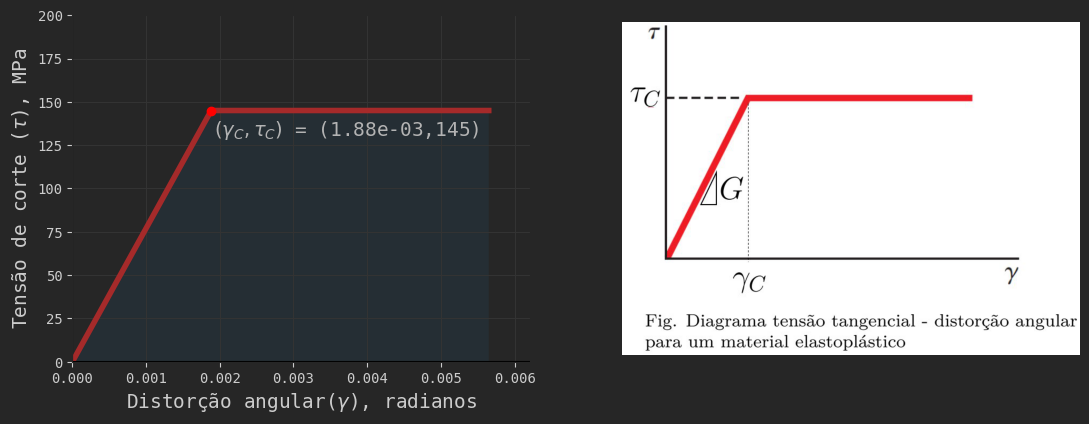

In [2]:
import imageio.v2 as iio

url1 = caminho + 'Au13_P003_i2.jpg'
img1 = iio.imread(url1)

gammaC = TauC/G
print('gammaC (TauC) = ','{:.5e}'.format(gammaC),' | ','{:.1f}'.format(gammaC*1e6),' microdef')
xlei = np.array([0,gammaC,3*gammaC])
ylei = np.array([0,TauC*1e-6,TauC*1e-6])

fig = plt.figure(figsize=(13,4.5))
ax1 = fig.add_subplot(1,2,1)
ax1.plot(xlei, ylei, '-', linewidth=4, color='brown')
plt.fill_between(xlei, ylei, alpha=.1)
plt.plot(xlei[1],ylei[1], 'ro')
x11, y11 = gammaC*1.02, TauC*1e-6*.9
ax1.text(x11, y11,rf'$(\gamma_C,\tau_C)$ = ({gammaC:.2e},{TauC*1e-6:.0f})')
plt.xlabel(r'Distorção angular($\gamma$), radianos',fontsize=14)
plt.ylabel(r'Tensão de corte ($\tau$), MPa',fontsize=14)
plt.xlim(0,xlei[-1]*1.1)
plt.ylim(0,ylei[-1]*1.1)
ax1.axhline(y=0, color='k')
ax1.axvline(x=0, color='k')
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.ylim(0,200)
ax1.grid()
ax2 = fig.add_subplot(1,2,2)
plt.imshow(img1)
plt.axis('off')
plt.show()

#### b) Sabendo que a extensão medida em $E$ é de 665 $\mu\varepsilon$, determine a intensidade do momento $T$ aplicado.<a name="B"></a>  ([_enunciatum_](#PV133))

Na figura seguinte ilustra-se a representação esquemática dos esforços aplicadas em elementos de área infinitesimais na superfície exterior do veio, orientados em dois sistemas de coordenadas: um com eixos paralelos aos eixos do veio e outro com eixos orientados a ângulos de $\pm45^\circ$:

<img src="https://userweb.fct.unl.pt/~jmc.xavier/MSI/Notebooks/Au13/Au13_P003_i3.jpg"
width="600" height="350">

- Análise do equilíbrio local

Considere-se um elemento de área infinitesimal na superfície do veio de área BCD (ver figura). No diagrama de corpo livre representa-se: (1) a força que atua sobre a área elementar exposta CD; (1) as forças de corte geradas pelo momento torsor nas facetas do elemento ao longo de BC e BD. Estas forças de corte são iguais em módulo pelo princípio da reciprocidade do tensor das tensões.

A análise do equilíbrio deste elemento permite escrever:

\begin{equation*}
F = 2(\tau_\mathrm{max}A_0)\sin(45^\circ{\scriptsize\frac{\pi}{180^\circ}})
= 2(\tau_\mathrm{max}A_0)\frac{\sqrt{2}}{2}
= \tau_\mathrm{max}A_0\sqrt{2}
\end{equation*}

em que $A_0$ representa a área da faceta. A tensão normal, por sua vez, pode ser calculada por:

\begin{equation*}
\sigma_{\pm45^\circ} = \displaystyle\frac{F}{A}
= \displaystyle\frac{\tau_\mathrm{max}A_0\sqrt{2}}
{A_0\sqrt{2}}
= \tau_\mathrm{max} \equiv \tau_{xz}
\end{equation*}

Na figura seguinte ilustram-se modos de rutura para vários tipos de materiais dúcteis e frágeis. Num modo de rutura por tração (típico para materiais frágeis) como previa a falha se o momento aplicado fosse invertido (momento torsor negativo) ?

<img src="https://userweb.fct.unl.pt/~jmc.xavier/MSI/Notebooks/Au13/Au13_P003_i4.jpg"
width="600" height="230">

No referencial do veio, $S(0,x,y,z)$, o estado de tensão aplicado, correspondente ao momento de torção puro, contem apenas tensões de corte no plano $x-z$:

\begin{equation*}
\underline{\underline{\sigma}} =
\begin{bmatrix}
0 & 0 & \tau_{xz} \\
0 & 0 & 0 \\
\tau_{xz} & 0 & 0 \\
\end{bmatrix}
\end{equation*}

- Pela análise do método do círculo de Mohr:


PLANO x-z: (NORMALIZADO)


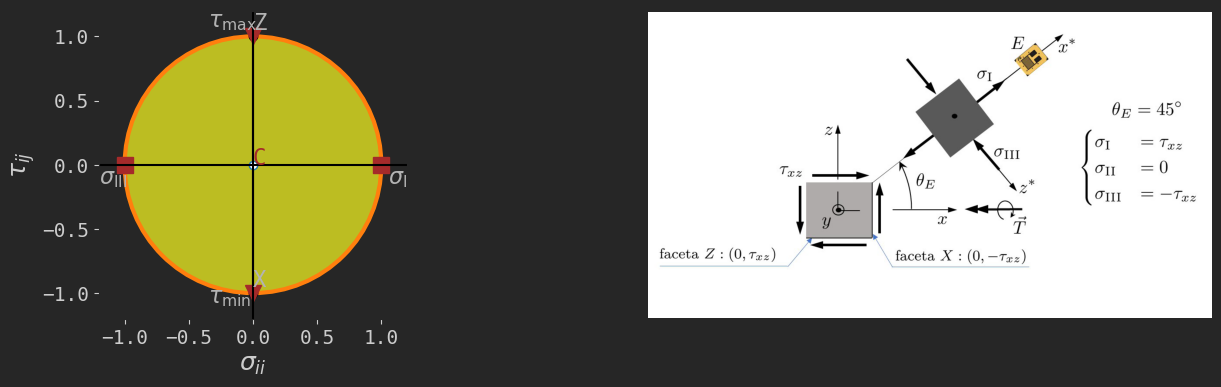

In [3]:
url6 = caminho + 'Au13_P003_i6.jpg'
img6 = iio.imread(url6)

url6 = caminho + 'Au13_P003_i6.jpg'
img6 = iio.imread(url6)

def mohr(S,limits):
    """Plot Mohr circle for a 2D tensor"""
    S11, S12, S22 = S[0][0], S[0][1], S[1][1]
    center = [(S11 + S22)/2.0, 0.0]
    radius = np.sqrt((S11 - S22)**2/4.0 + S12**2)
    Smin, Smax = center[0] - radius, center[0] + radius

    fig = plt.figure(figsize=(16,4))
    ax1 = fig.add_subplot(1,2,1)
    circ = plt.Circle((center[0],0), radius, facecolor='tab:olive', lw=3,
    edgecolor='tab:orange')
    desv = 0.1*radius
    plt.axis('image')
    ax1 = plt.gca()
    ax1.add_artist(circ)
    ax1.set_xlim(Smin - .3*radius, Smax + .3*radius)
    ax1.set_ylim(-1.3*radius, 1.3*radius)
    plt.plot([S11, S22], [-S12, S12], 'ko')
    plt.plot([S11, S22], [-S12, S12], 'k')
    plt.plot(Smin, 0, 's', markersize=12,color='brown')
    plt.plot(Smax, 0, 's', markersize=12,color='brown')
    plt.plot(center[0], radius,'v', markersize=12,color='brown')
    plt.plot(center[0], -radius,'v', markersize=12,color='brown')
    plt.plot(center[0], center[1], 'o', mfc='w')
    plt.text(center[0], 0, 'C',size=16,color='brown')
    plt.text(S11, -S12*.95, 'X',size=16)
    plt.text(S22, S12*1.05, 'Z',size=16)
    plt.text(Smin*1.2, -0.15*radius, r'$\sigma_\mathrm{III}$',size=16)
    plt.text(Smax*1.05, -0.15*radius, r'$\sigma_\mathrm{I}$',size=16)
    plt.text(center[0]-3.5*desv, 1.075*radius, r'$\tau_\mathrm{max}$',size=16)
    plt.text(center[0]-3.5*desv, -1.075*radius, r'$\tau_\mathrm{min}$',size=16)
    plt.xlabel(r"$\sigma_{ii}$", size=18)
    plt.ylabel(r"$\tau_{ij}$", size=18)
    plt.xlim(limits[0,0],limits[0,1])
    plt.ylim(limits[1,0],limits[1,1])
    ax1.axhline(y=0, color='k')
    ax1.axvline(x=0, color='k')
    ax2 = fig.add_subplot(1,2,2)
    plt.imshow(img6)
    plt.axis('off')
    plt.show()

axislim = np.array([[-1.2,1.2],[-1.2,1.2]])
print('\n================================')
print('PLANO x-z: (NORMALIZADO)')
print('================================')
sxx, szz, sxz = 0., 0., 1. # valor normalizado
S = np.array([[sxx, sxz],[sxz, szz]])
mohr(S, axislim)

center, radius = (sxx + szz)/2, np.sqrt((sxx - szz)**2/4.0 + sxz**2)
smax, smin = center + radius, center - radius

- Pela lei de transformação do estado plano de tensão

A transformação do referencial $S(O,x,z)$ para um referencial artitrário obtido por rotação em torno de um eixo comum (eixo dos $yy$) de um ângulo $\theta$,  permite concluir, uma vez que apenas existe componente de tensão de corte $\tau_{xz}$:

\begin{equation*}
\begin{cases}
\sigma_{n} = \tau_{xz}\sin2\theta \\
\tau_{nt} = \tau_{xz}\cos2\theta \\
\end{cases}
\end{equation*}

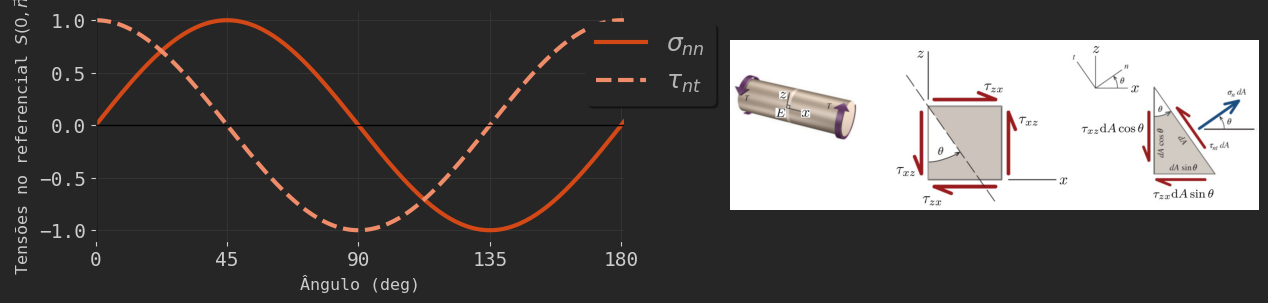

In [4]:
def S11t(S11,S22,S12,t):
    return (S11+S22)/2 + (S11-S22)/2*np.cos(2*t) + S12*np.sin(2*t)

def S22t(S11,S22,S12,t):
    return (S11+S22)/2 - (S11-S22)/2*np.cos(2*t) - S12*np.sin(2*t)

def S12t(S11,S22,S12,t):
    return (S22-S11)/2*np.sin(2*t) + S12*np.cos(2*t)

def angPrincipal(S11,S22,S12):
    return np.arctan(2*S12/(S11-S22))/2

def angS(s11,s22,s12): return -np.arctan((s11-s22)/(2*s12))

url7 = caminho + 'Au13_P003_i7.jpg'
img7 = iio.imread(url7)

sxx, txz, szz = 0, 1, 0

angt = np.arange(0,182,1)
snn = txz*np.sin(2*np.deg2rad(angt))
tnt = txz*np.cos(2*np.deg2rad(angt))

fig = plt.figure(figsize=(15,3))
ax1 = fig.add_subplot(1,2,1)
ax1.plot(angt, snn, '-', color="#D34817", label=r'$\sigma_{nn}$', linewidth=3)
ax1.plot(angt, tnt, '--', color="#EF8C6A", label=r'$\tau_{nt}$', linewidth=3)
plt.xlabel(r'Ângulo (deg)',fontsize=12)
plt.ylabel(r'Tensões no referencial $S(0,\vec{n},\vec{t})$',fontsize=12)
legend = ax1.legend(bbox_to_anchor=(1.05, 1), loc='upper center',
                   shadow=True, fontsize=18, facecolor=(.15,.15,.15),
                   edgecolor=(.15,.15,.15))
ax1.axhline(y=0, color='k', linewidth=1)
ax1.axvline(x=0, color='k', linewidth=1)
ax1.set(xlim=(0, angt[-1]))
xlabels = ['0','45','90','135','180']
plt.xticks(np.arange(angt[0], angt[-1], 45),xlabels)
ax1.xaxis.set_major_formatter(ticker.FormatStrFormatter('%0.0f'))
ax1.grid()
ax3 = fig.add_subplot(1,2,2)
plt.imshow(img7)
plt.axis('off')
plt.show()

No referencial princial $S(0,x^*,y^*,z^*)$ a lei de Hooke permite relacionar a extensão linear na direção dos $x^*$ com as componentes das tensões principais pela relação:

\begin{equation*}
\varepsilon_E \equiv \varepsilon_{x^*}
= \frac{1}{E}[\sigma_\mathrm{I} - \nu(\sigma_\mathrm{II} + \sigma_\mathrm{III} )]
= 665~\textrm{$\mu$m}
\end{equation*}

de onde se pode retirar ($\sigma_\mathrm{III} = -\tau_{xz},
\sigma_\mathrm{II} = 0, \sigma_\mathrm{I} = \tau_{xz} $),

\begin{equation*}
\varepsilon_E = \frac{1}{E}(\tau_{xz} + \nu\tau_{xz})
= \frac{1}{E}(1 + \nu)\tau_{xz} = \frac{1}{2G}\tau_{xz}
= 665~\textrm{$\mu$m}
\end{equation*}

In [5]:
from sympy.solvers import solve
from sympy import symbols

tauxz = symbols('tauxz')

def eE(E,nu,sI,sII,sIII): return (sI-nu*(sII+sIII))/E

sol = solve([eE(E,nu,tauxz,0,-tauxz) - epsE], [tauxz], dict=True)
tauxz1 = float(sol[0][tauxz])
print(f'versão 1 :: tauzx1 = {tauxz1*1e-6:.2f} MPa')

tauxz2 = epsE*E/(1+nu)
print(f'versão 2 :: tauzx2 = {tauxz2*1e-6:.2f} MPa')

tauxz3 = epsE*2*G
print(f'versão 3 :: tauzx3 = {tauxz3*1e-6:.2f} MPa')

versão 1 :: tauzx1 = 102.41 MPa
versão 2 :: tauzx2 = 102.41 MPa
versão 3 :: tauzx3 = 102.41 MPa


Calculando a matriz do tensor das tensões no referencial principal:

\begin{equation*}
\begin{aligned}
[\sigma]_P &= [T_{0P}]\,[\sigma]_0\,[T_{0P}]^{\mathrm{T}}
= \begin{bmatrix}
\tau_{xz} & 0 & 0 \\
0 & 0 & 0 \\
0 & 0 & -\tau_{xz}
\end{bmatrix}
\end{aligned}
\end{equation*}

In [6]:
np.set_printoptions(precision=3,suppress=True)

def Q(ang,rot):
    c, s = np.cos(ang), np.sin(ang)
    if rot == 1:
        Qij = np.array([[1,0,0],[0,c,s],[0,-s,c]])
    elif rot == 2:
        Qij = np.array([[c,0,s],[0,1,0],[-s,0,c]])
    else:
        Qij = np.array([[c,s,0],[-s,c,0],[0,0,1]])
    return Qij

T0P = Q(np.deg2rad(45),2)

def mtensoes(sXX,sXY,sXZ,sYY,sYZ,sZZ):
    return np.array([[sXX,sXY,sXZ],[sXY,sYY,sYZ],[sXZ,sYZ,sZZ]])

tt0 = mtensoes(0,0,tauxz1*1e-6,0,0,0)
print('- matriz das tensões - S(x,y,z) : \n',tt0,' [MPa]')

ttP = np.dot(T0P,np.dot(tt0,np.transpose(T0P)))
print('\n- matriz das tensões - Referencial principal: \n',ttP,' [MPa]')

- matriz das tensões - S(x,y,z) : 
 [[  0.     0.   102.41]
 [  0.     0.     0.  ]
 [102.41   0.     0.  ]]  [MPa]

- matriz das tensões - Referencial principal: 
 [[ 102.41    0.      0.  ]
 [   0.      0.      0.  ]
 [   0.      0.   -102.41]]  [MPa]


O estado de tensão de corte instalado no veio $CD$ (no veio da leitura do extensómetro) pela aplicação do momento torsor é de $\tau_{xz} = 102.41$ MPa, ou seja, o veio está no domínio elástico uma vez que se verifica: $\tau_{xz} <
\tau_C$ ($\tau_C = 145$ MPa).

Assim sendo, pela fórmula de torção o momento torsor aplicado pode ser deterinado por:

\begin{equation*}
T = \frac{\tau_{xz} J_{CD}}{r_{CD}}
\quad\wedge\quad J_{CD} = \frac{\pi}{2}r_{CD}^4
\quad\therefore~
\quad T = \frac{\pi r_{CD}^3}{2}\tau_{xz}
= \pi G r_{CD}^3\varepsilon_E
\quad\textrm{(sinal negativo : sentido horário)}
\end{equation*}

In [7]:
JCD = np.pi/2*rCD**4
print(f'JCD = {JCD:.5e} m^4')
T = tauxz1*JCD/rCD
print(f'T = {T:.2f} N.m (sinal negativo : sentido horário)')


JCD = 4.02124e-06 m^4
T = 10295.38 N.m (sinal negativo : sentido horário)


#### c) Para o momento de torção calculado na alínea anterior, determine a distribuição de tensões tangenciais nos três troços do veio.<a name="C"></a>([_enunciatum_](#PV133))

- Veio $AB$:

O momento de torção crítico é calculado por:

\begin{equation*}
\left.T_C = \frac{J}{r_e}\tau_C\right|_{AB}
\quad\wedge\quad
\left.J = \frac{\pi}{2}(r_e^4-r_i^4)\right|_{AB}
\end{equation*}

In [8]:
JAB = np.pi/2*(rABe**4 - rABi**4)
print(f'JAB = {JAB:.5e} m^4')

Tc = TauC*JAB/rABe
print(f'TcAB = {Tc:.2f} N.m')

JAB = 3.37623e-06 m^4
TcAB = 9791.07 N.m


Comece-se por calcular a tensão de corte que é gerada no troço no veio $AB$ pelo momento de torção $T$, calculado na alínea anterior. Por hipótese, assuma-se numa primeira iteração de que o comportamento do veio é elástico e portanto é válida a fórmula de torsão:

\begin{equation*}
\tau_{xz}^{AB} = \frac{Tr_{AB,e}}{J_{AB}}
\quad\wedge\quad
J_{AB} = \frac{\pi}{2}(r_{AB,e}^4-r_{AB,i}^4)
\quad\therefore\quad
\tau_{xz}^{AB} = \frac{2\,r_{AB,e}}{\pi(r_{AB,e}^4-r_{AB,i}^4)}T
\end{equation*}

In [9]:
tauxzABre = T*rABe/JAB
print(f'tau AB (re) = {tauxzABre*1e-6:.2f} MPa')

tauxzABre2 = 2*T*rABe/np.pi/(rABe**4 - rABi**4)
print(f'tau AB (re) (versão 2) = {tauxzABre2*1e-6:.2f} MPa')

tau AB (re) = 152.47 MPa
tau AB (re) (versão 2) = 152.47 MPa


Para o valor da tensão de corte na superfície exterior ($\rho = r_e$) do troço oco do veio $AB$ ocorrerá plasticidade pois: $\tau_{xz}(\rho = r_e) > \tau_C$ ($\tau_C = 145$ MPa).

Em alternativa poder-se-ia determinar o momento máximo elástico $T_C$ e confrontar esse valor com o momento aplicado de $T=$ 10295.38 N.m ($\tau_{xz}$).

Deve-se seguidamente verificar se a secção do veio oco está parcialmente (com núcleo elástico circunscrito por uma coroa plástica) ou totalmente plástica. Para o efeito, calcule-se o raio crítico de transição entre a região elástica e a zona plástica. Este cálculo pode ser obtido a partir da expressão do momento torsor plástico (válido no regime plástico), $T \equiv T_p$, cuja expressão pode ser resolvida para a posição radial crítica, $\rho_C$:

\begin{equation*}
T = 2\pi \int_{\rho_c}^{r_e} \rho^2\tau_C\mathrm{d}\rho
= 2\pi~\tau_C \left[\frac{\rho_c^3}{3}\right]_{\rho_c}^{r_e}
= \frac{2\pi}{3}\tau_C(r_e^3 - \rho_c^3)
\quad\Leftrightarrow\quad
\rho_C = \left({r_e^3-\frac{3}{2\pi}\frac{T}{\tau_C}}\right)^{1/3}
\end{equation*}

In [10]:
rhoCAB = (rABe**3- 3/2/np.pi*T/TauC)**(1/3)
print(f'rhoCAB = {rhoCAB*1e3:.1f} mm')

rhoCAB = 45.0 mm


O valor de $\rho_C^{AB}$ é igual ao valor do raio interior do veio oco $AB$ ($r_i \equiv r_{AB,i}$), pelo que se pode considerar que o veio está completamente plástico. O valor do momento de torção plástico é efetivamente igual ao momento torsor aplicado, $T_p$:

\begin{equation*}
T_p  = \frac{2\pi}{3}\tau_C(r_e^3 - r_i^3)
\end{equation*}

In [11]:
TpAB = 2/3*np.pi*TauC*(rABe**3 - rhoCAB**3)
print(f'TpAB = {TpAB:.1f} N.m')

TpAB = 10295.4 N.m


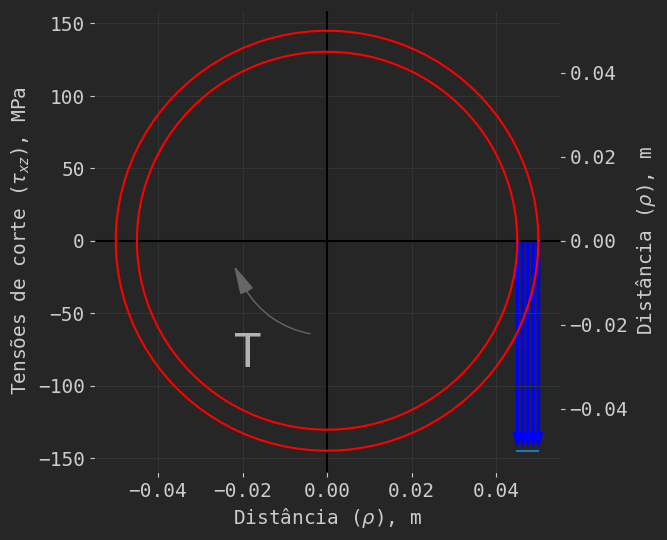

In [12]:
def torcao(rho,T,J): return T*rho/J

def distab():
    limits = np.array([[-rABe*1.1,rABe*1.1],[-TauC*1.1*1e-6,TauC*1.1*1e-6]])
    xp1 = np.linspace(rABi,rABe,5)
    yp1 = -np.ones(xp1.shape)*TauC*1e-6
    fig, ax = plt.subplots(figsize=(6,6))
    ax2 = ax.twinx()
    ax.plot(xp1,yp1)
    ax.quiver(xp1, np.zeros(xp1.shape), np.zeros(xp1.shape), yp1,color='blue', scale=325)
    ax.set(xlabel=r'Distância ($\rho$), m', ylabel=r'Tensões de corte ($\tau_{xz}$), MPa')
    theta = np.linspace(0, 2*np.pi, 100)
    x1i, x2i = rABi*np.cos(theta), rABi*np.sin(theta)
    ax2.plot(x1i, x2i,color='red')
    x1e, x2e = rABe*np.cos(theta), rABe*np.sin(theta)
    ax2.plot(x1e, x2e,color='red')
    ax2.set(ylabel=r'Distância ($\rho$), m')
    x0, y0, angle = 0., 0., 260.
    angle_rad = angle * math.pi / 180
    arc_radius = rABi
    arc = Arc((x0, y0),arc_radius, arc_radius,theta1=210, theta2=260, linestyle='solid',color=(0.4,0.4,0.4))
    ax2.add_patch(arc)
    arc_arrow_length = rABi/2
    arc_arrow_dx = arc_arrow_length * math.cos(angle_rad + math.pi / 2)
    arc_arrow_dy = arc_arrow_length * math.sin(angle_rad + math.pi / 2)
    ax2.arrow(-0.019,-0.012,-.005* 0.01,0.01* 0.01,head_width=0.003,head_length=0.006,color=(0.4,0.4,0.4))
    ax2.text(-.022,-.03,'T',fontsize=33)
    ax.set_xlim(limits[0,0],limits[0,1])
    ax.set_ylim(limits[1,0],limits[1,1])
    ax2.set_ylim(limits[0,0],limits[0,1])
    ax.axhline(y=0, color='k')
    ax.axvline(x=0, color='k')
    ax.grid()
    plt.show()

distab()

- Veio $BC$:

No troço do veio $BC$ a distribuição da tensão de corte é linear ao longo do veio aonde permanece válido o regime elástico, pelo que da fórmula de torção vem:

\begin{equation*}
\tau_{BC} \equiv \tau(\rho) = \frac{T}{J_{BC}}\rho = 1,05\times 10^9 \rho
\quad | \quad
\rho = r_e^{BC}~:
\quad\Rightarrow\quad
\tau(r_e) = 52,4~\textrm{MPa}
\end{equation*}

In [13]:
JBC = np.pi/2*rBC**4
print(f'JBC = {JBC:.5e} m^4')
coefBC = T/JBC
print(f'coefBC = T\JBC = {coefBC:.2e}')
tauxzBC = T*rBC/JBC
print(f'tau BC = {tauxzBC*1e-6:.2f} MPa')

JBC = 9.81748e-06 m^4
coefBC = T\JBC = 1.05e+09
tau BC = 52.43 MPa


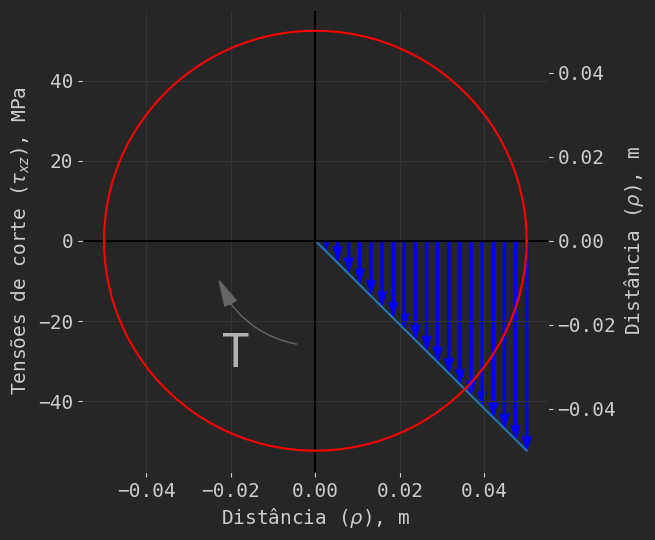

In [14]:
limits = np.array([[-rBC*1.1,rBC*1.1],[-tauxzBC*1.1*1e-6,tauxzBC*1.1*1e-6]])
xp1 = np.linspace(0,rBC,20)
yp1 = torcao(xp1,-T,JBC)*1e-6
fig, ax = plt.subplots(figsize=(6,6))
ax2 = ax.twinx()
ax.plot(xp1,yp1)
ax.quiver(xp1, np.zeros(xp1.shape), np.zeros(xp1.shape), yp1,color='blue', scale=115)
ax.set(xlabel=r'Distância ($\rho$), m', ylabel=r'Tensões de corte ($\tau_{xz}$), MPa')
theta = np.linspace(0, 2*np.pi, 100)
x1, x2 = rBC*np.cos(theta), rBC*np.sin(theta)
ax2.plot(x1, x2,color='red')
ax2.set(ylabel=r'Distância ($\rho$), m')
x0, y0, angle, arc_radius = 0, 0, 260, rBC
angle_rad = angle * math.pi / 180
arc = Arc((x0, y0),arc_radius, arc_radius,theta1=210, theta2=260,
          linestyle='solid',color=(0.4,0.4,0.4))
ax2.add_patch(arc)
arc_arrow_length = rBC/2
ax2.arrow(-0.020,-0.015,-.005* 0.01,0.01* 0.01,head_width=0.003,head_length=0.006,color=(0.4,0.4,0.4))
ax2.text(-.022,-.03,'T',fontsize=33)
ax.set_xlim(limits[0,0],limits[0,1])
ax.set_ylim(limits[1,0],limits[1,1])
ax2.set_ylim(limits[0,0],limits[0,1])
ax.axhline(y=0, color='k')
ax.axvline(x=0, color='k')
ax.grid()
plt.show()

- Veio $CD$:

No troço do veio $CD$ a distribuição da tensão de corte é linear ao longo do veio aonde permanece válido o regime elástico, pelo que da fórmula de torção vem:

\begin{equation*}
\tau_{CD} \equiv \tau(\rho) = \frac{T}{J_{CD}}\rho = 2,56\times 10^9 \rho
\quad | \quad
\rho = r_e^{CD}~:
\quad\Rightarrow\quad
\tau(r_e) = 102,3~\textrm{MPa}
\end{equation*}

In [15]:
coefCD = T/JCD
print(f'coefCD = T\JCD = {coefCD:.2e}')
txzCDre = coefCD*rCD
print(f'txz CD (re) = {txzCDre*1e-6:.2f} MPa')

coefCD = T\JCD = 2.56e+09
txz CD (re) = 102.41 MPa


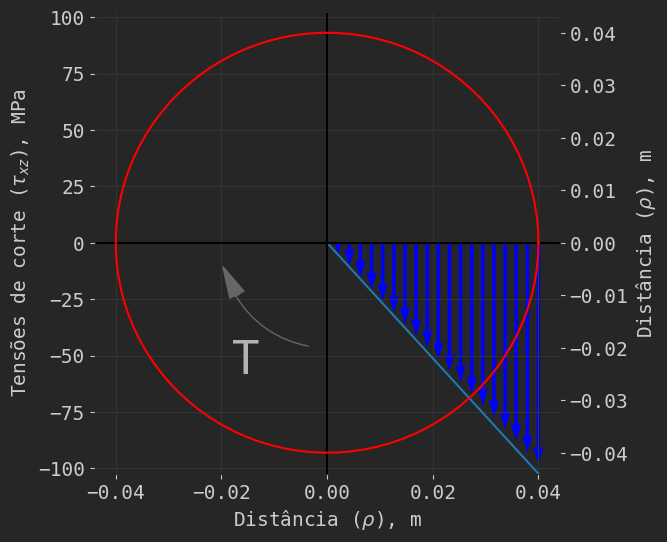

In [16]:
tauxzCD = tauxz1*1e-6

limits = np.array([[-rCD*1.1,rCD*1.1],[-tauxzCD,tauxzCD]])
xp1 = np.linspace(0,rCD,20)
yp1 = torcao(xp1,-T,JCD)*1e-6
fig, ax = plt.subplots(figsize=(6,6))
ax2 = ax.twinx()
ax.plot(xp1,yp1)
ax.quiver(xp1, np.zeros(xp1.shape), np.zeros(xp1.shape), yp1,color='blue', scale=215)
ax.set(xlabel=r'Distância ($\rho$), m', ylabel=r'Tensões de corte ($\tau_{xz}$), MPa')
theta = np.linspace(0, 2*np.pi, 100)
x1 = rCD*np.cos(theta)
x2 = rCD*np.sin(theta)
ax2.plot(x1, x2,color='red')
ax2.set(ylabel=r'Distância ($\rho$), m')
x0, y0, angle, arc_radius = 0, 0, 260, rCD
angle_rad = angle * math.pi / 180
arc = Arc((x0, y0),arc_radius, arc_radius,theta1=210, theta2=260,
          linestyle='solid',color=(0.4,0.4,0.4))
ax2.add_patch(arc)
ax2.arrow(-0.017,-0.01,-.005* 0.01,0.01* 0.01,head_width=0.003,head_length=0.006,color=(0.4,0.4,0.4))
ax2.text(-.018,-.025,'T',fontsize=33)
ax.set_xlim(limits[0,0],limits[0,1])
ax.set_ylim(limits[1,0],limits[1,1])
ax2.set_ylim(limits[0,0],limits[0,1])
ax.axhline(y=0, color='k')
ax.axvline(x=0, color='k')
ax.grid()
plt.show()

#### d) Devido ao momento $T$ aplicado, mediu-se uma rotação da secção $D$, $\phi_D$ = 3,5º. Determine a rotação que existirá nessa secção quando o  momento $T$ for retirado, assim como a distribuição de tensões residuais  no veio.<a name="D"></a> ([_enunciatum_](#PV133))

**Ângulo de torção residual**

O ângulo de torção do veio $AC$ é obtido pelo sumatório dos ângulos relativos de cada troço (em série) que o constitui:

\begin{equation*}
\phi_{D/A} \equiv \phi_{D} = \phi_{D/C} + \phi_{C/B} + \phi_{B/A}
= \phi_{D/C} + \phi_{C/B} + \phi_{B}
\end{equation*}

Esta última expressão pode ser resolvida para o ângulo $\phi_{B}$ (do troço no regime plástico):

\begin{equation*}
\phi_{B} = \phi_{D} - \phi_{D/C} - \phi_{C/B}
\quad\wedge\quad
\phi_D = 3,5º
\end{equation*}

Uma vez que o veio $CD$ está no domínio elástico:

\begin{equation*}
\phi_{D/C}  = \frac{TL_{CD}}{J_{CD}G}
\end{equation*}

In [17]:
phiDC = T*LCD/JCD/G
print(f'phi D\C = {phiDC:.4f} rad | {np.rad2deg(phiDC):.3f} º')

phi D\C = 0.0133 rad | 0.762 º


Por seu lado, o veio $BC$ também permanece no domínio elástico:

\begin{equation*}
\phi_{C/B}  = \frac{TL_{BC}}{J_{BC}G}
\end{equation*}

In [18]:
phiCB = T*LBC/JBC/G
print(f'phi C\B = {phiCB:.5f} rad | {np.rad2deg(phiCB):.3f} º')

phi C\B = 0.00272 rad | 0.156 º


Pelo que o ângulo de torção no troço do veio $AB$ (no domínio plástico) vem:

In [19]:
phiB = phiD - phiDC - phiCB
print(f'phi B\A = {phiB:.4f} rad | {np.rad2deg(phiB):.3f} º')

phi B\A = 0.0451 rad | 2.582 º


O ângulo de torção residual é determinado pelo princípio da sobreposição e vem dado por:

\begin{equation*}
\phi_{B}^R  = \phi_{B} - \phi_{B\,{'}}
\end{equation*}

com,

\begin{equation*}
\begin{cases}
\phi_{B} =  \phi_{D} - \displaystyle\frac{TL_{BC}}{J_{BC}G} - \displaystyle\frac{TL_{CD}}{J_{CD}G} \\
\phi_{B\,{'}} = \displaystyle\frac{TL_{AB}}{J_{AB}G}
\end{cases}
\end{equation*}

In [20]:
phiBdescarga = T*LAB/JAB/G
print(f'phi B\A Descarga = {phiBdescarga:.4f} rad | {np.rad2deg(phiBdescarga):.2f} º')
phiBredisual = phiB - phiBdescarga
print(f'phi B\A Residual = {phiBredisual:.4f} rad | {np.rad2deg(phiBredisual):.2f} º')

phi B\A Descarga = 0.0238 rad | 1.36 º
phi B\A Residual = 0.0213 rad | 1.22 º


Tendo em conta a compatibilidade de ângulos de torção e atendendo a que o troço $AB$ plastificou têm-se:

\begin{equation*}
\phi_{D/C}^R  = \phi_{C/B}^R = \phi_{B}^R
\end{equation*}

In [21]:
phiC = TauC*LAB/G/rABe
print(f'phiC = {phiC:.4f} rad | {np.rad2deg(phiC):.2f} º')

phiC = 0.0226 rad | 1.29 º


<img src="https://userweb.fct.unl.pt/~jmc.xavier/MSI/Notebooks/Au13/Au13_P003_i8.jpg"
width="600">

**Tensões de corte residuais**

As tensões residuais no material elastoplástico são obtidas por aplicando o princípio de superposição.

Por um lado, consideram-se as tensões devidas à aplicação do momento torsor, $T$.
Por outro lado, são consideradas as tensões devido ao momento de torção, igual e oposto, que é aplicado na fase de descarga.

O primeiro grupo de tensões reflete o comportamento elasto-plástico do material durante a fase de carregamento.
O segundo grupo tem o comportamento linear do mesmo material durante o estágio de descarga.
A adição dos dois grupos de tensões fornece a distribuição das tensões residuais no eixo.

Na descarga, a tensão mínima ($\tau_\mathrm{min}$) e máxima ($\tau_\mathrm{max}$) lineares no interior ($r_i$) e exterior ($r_e$) do tubo vêm:

\begin{equation*}
\begin{cases}
\tau_\mathrm{max} \equiv \tau_\mathrm{e} &= \displaystyle\frac{(-T_P)
r_e}{J_{AB}} \\
\tau_\mathrm{min} \equiv \tau_\mathrm{i} &=
\displaystyle\frac{(-T_P) r_i}{J_{AB}} =
\tau_\mathrm{max} \displaystyle\frac{r_i}{r_e}\\
\end{cases}
\end{equation*}

In [22]:
taumaxABDescarga =  -TpAB*rABe/JAB
print(f'tau max -veio AB- (Descarga) = {taumaxABDescarga*1e-6:.2f} MPa')

tauminABDescarga =  -TpAB*rABi/JAB
print(f'tau min -veio AB- (Descarga) = {tauminABDescarga*1e-6:.2f} MPa')

tauminABDescarga2 =  taumaxABDescarga*rABi/rABe
print(f'tau min -veio AB- (Descarga) (versão 2) = {tauminABDescarga2*1e-6:.2f} MPa')

tau max -veio AB- (Descarga) = -152.47 MPa
tau min -veio AB- (Descarga) = -137.22 MPa
tau min -veio AB- (Descarga) (versão 2) = -137.22 MPa


Assim sendo as tensões residuais têm uma distribuição linear cujos valores no ponto interior e exterior ao veio oco são
determinados por:

\begin{equation*}
\tau_i^R = \tau_C + \tau_\mathrm{min}
\quad\wedge\quad
\tau_e^R = \tau_C + \tau_\mathrm{max}
\end{equation*}

In [23]:
tauresidualri = TauC + tauminABDescarga
print(f'tau Residual (ri) = {tauresidualri*1e-6:.2f} MPa')

tauresidualre = TauC + taumaxABDescarga
print(f'tau Residual (re) = {tauresidualre*1e-6:.2f} MPa')


tau Residual (ri) = 7.78 MPa
tau Residual (re) = -7.47 MPa


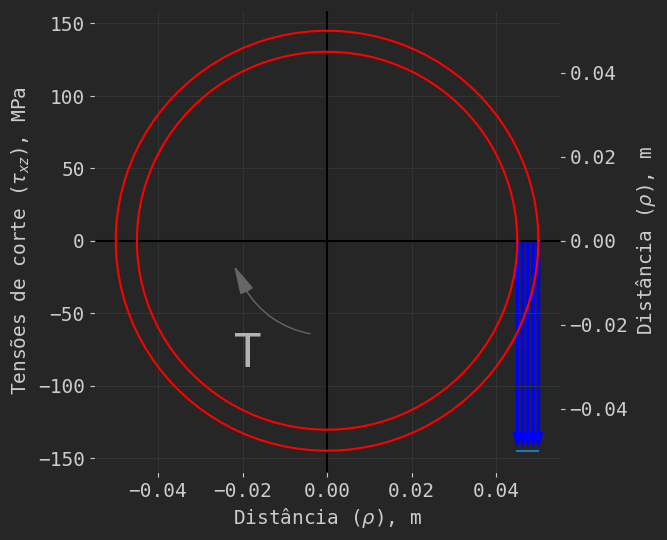

In [24]:
distab()

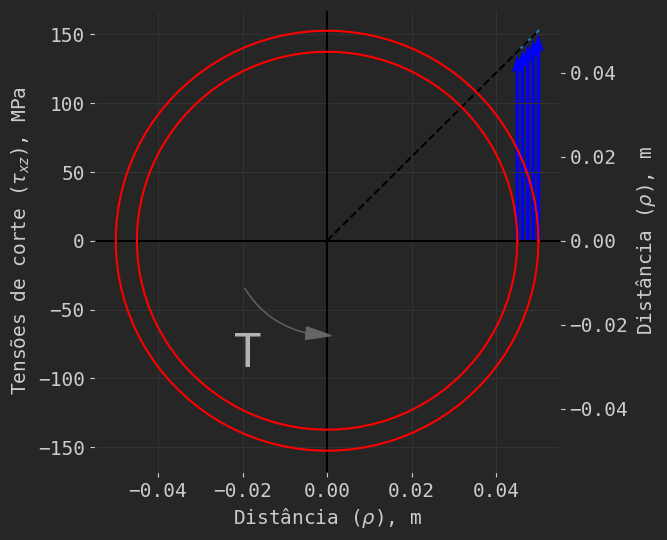

In [25]:
Tplt1 = tauminABDescarga*1e-6 # unidade: MPa
Tplt2 = taumaxABDescarga*1e-6

limits = np.array([[-rABe*1.1,rABe*1.1],[Tplt2*1.1,-Tplt2*1.1]])
xp1 = np.linspace(rABi,rABe,5)
yp1 = TpAB*xp1/JAB*1e-6
fig, ax = plt.subplots(figsize=(6,6))
ax2 = ax.twinx()
ax.plot(xp1,yp1)
ax.plot([0,xp1[-1]],[0,yp1[-1]],'k--')
ax.quiver(xp1, np.zeros(xp1.shape), np.zeros(xp1.shape), yp1,color='blue', scale=343)
ax.set(xlabel=r'Distância ($\rho$), m', ylabel=r'Tensões de corte ($\tau_{xz}$), MPa')
theta = np.linspace(0, 2*np.pi, 100)
x1i, x2i = rABi*np.cos(theta), rABi*np.sin(theta)
ax2.plot(x1i, x2i,color='red')
x1e, x2e = rABe*np.cos(theta), rABe*np.sin(theta)
ax2.plot(x1e, x2e,color='red')
ax2.set(ylabel=r'Distância ($\rho$), m')
x0, y0, angle, arc_radius = 0, 0, 260, rABi
angle_rad = angle * math.pi / 180
arc = Arc((x0, y0),arc_radius, arc_radius,theta1=210, theta2=260,linestyle='solid',color=(0.4,0.4,0.4))
ax2.add_patch(arc)
arc_arrow_length = rABi/2
arc_arrow_dx = arc_arrow_length * math.cos(angle_rad + math.pi / 2)
arc_arrow_dy = arc_arrow_length * math.sin(angle_rad + math.pi / 2)
ax2.arrow(-0.005,-0.022,0.005* 0.01,-.0005* 0.01,head_width=0.003,head_length=0.006,color=(0.4,0.4,0.4))
ax2.text(-.022,-.03,'T',fontsize=33)
ax.set_xlim(limits[0,0],limits[0,1])
ax.set_ylim(limits[1,0],limits[1,1])
ax2.set_ylim(limits[0,0],limits[0,1])
ax.axhline(y=0, color='k')
ax.axvline(x=0, color='k')
ax.grid()
plt.show()

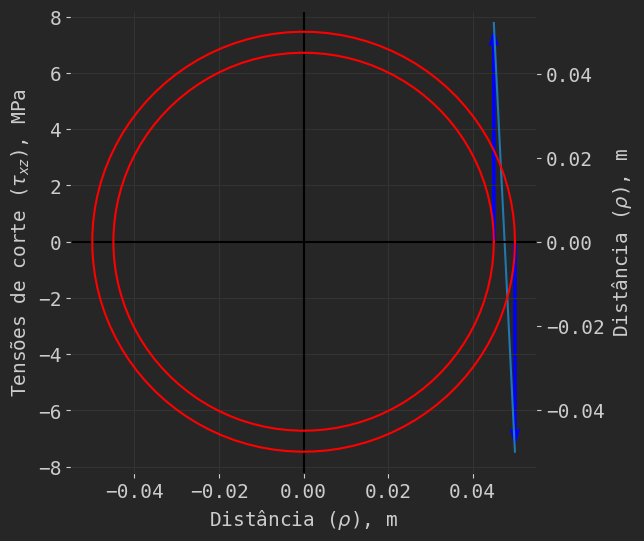

In [26]:
TauR1 = tauresidualri*1e-6 # unidades: MPa
TauR2 = tauresidualre*1e-6

limits = np.array([[-rABe*1.1,rABe*1.1],[TauR2*1.1,-TauR2*1.1]])
xp1 = np.array([rABi,rABe])
yp1 = np.array([TauR1,TauR2])
fig, ax = plt.subplots(figsize=(6,6))
ax2 = ax.twinx()
ax.plot(xp1,yp1)
ax.quiver(xp1, np.zeros(xp1.shape), np.zeros(xp1.shape), yp1,color='blue', scale=17)
ax.set(xlabel=r'Distância ($\rho$), m', ylabel=r'Tensões de corte ($\tau_{xz}$), MPa')
theta = np.linspace(0, 2*np.pi, 100)
x1i = rABi*np.cos(theta)
x2i = rABi*np.sin(theta)
ax2.plot(x1i, x2i,color='red')
x1e = rABe*np.cos(theta)
x2e = rABe*np.sin(theta)
ax2.plot(x1e, x2e,color='red')
ax2.set(ylabel=r'Distância ($\rho$), m')
ax.set_xlim(limits[0,0],limits[0,1])
ax.set_ylim(limits[1,0],limits[1,1])
ax2.set_ylim(limits[0,0],limits[0,1])
ax.axhline(y=0, color='k')
ax.axvline(x=0, color='k')
ax.grid()
plt.show()

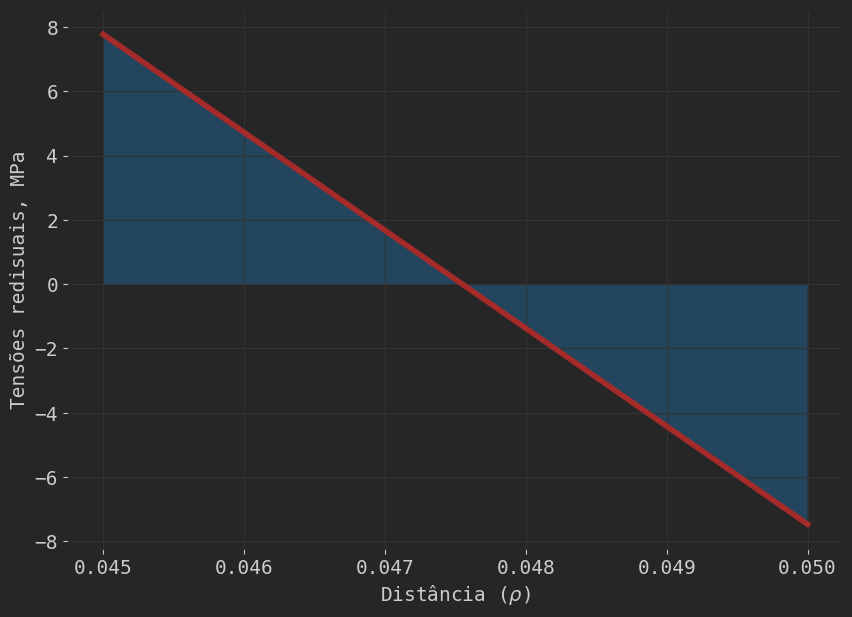

Int =  0.0


In [27]:
fig, ax = plt.subplots(figsize=(10,7))
# rho in [0,rhoC]
ax.plot(xp1, yp1, '-', linewidth=4, color='brown')
plt.fill_between(xp1,yp1, alpha=.4)
ax.set(xlabel=r'Distância ($\rho$)', ylabel='Tensões redisuais, MPa')
ax.grid()
plt.show()

IntegralT0a = np.trapz(yp1,xp1,dx = 10,axis=0)
print('Int = ', '{:.1f}'.format(IntegralT0a))

##### Bibliografia

[1]  Ferdinand P. Beer, E. Russell Johnston Jr., John T. DeWolf, David F. Mazurek. Mechanics of Materials. McGraw-Hill Education, 2014.

[2] Russell C. Hibbeler. Mechanics of Materials. Pearson, 2016.

[3] Timothy A. Philpot. Mechanics of materials: an integrated learning system. John Wiley & Sons, 2017.

---

Copyright (c) [Mecânica dos Sólidos I - DEMI - NOVA-SST]

Interactive computing by <a href="https://jupyter.org/" target="_blank"> <span
style="color:#333399"> Jupyter Notebook </span> </a> &nbsp;|&nbsp;Coded by <a href = "mailto: jmc.xavier@fct.unl.pt">José Xavier</a>

Licensed under  <a href="http://creativecommons.org/licenses/by-sa/4.0/"
target="_blank"> <span style="color:#333399;font-size: 20px"> CC BY-SA 4.0  </span></a>
